In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/HIII/banking-fraud-detection/data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [7]:
!pip install imbalanced-learn

In [8]:
from imblearn.over_sampling import SMOTE

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [10]:
print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:

Class
0    227451
1    227451
Name: count, dtype: int64


In [11]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(454902, 30)
(454902,)


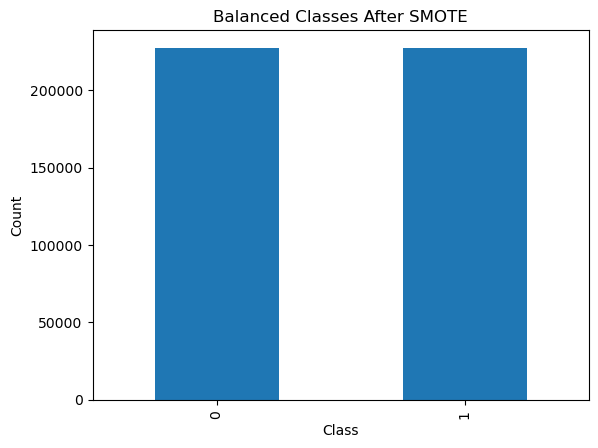

In [12]:
import matplotlib.pyplot as plt

y_train_smote.value_counts().plot(kind="bar")

plt.title("Balanced Classes After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [14]:
import os

print(os.getcwd())


C:\Users\HIII


In [17]:
np.save("C:/Users/HIII/banking-fraud-detection/data/X_train_smote.npy", X_train_smote)

np.save("C:/Users/HIII/banking-fraud-detection/data/X_test_scaled.npy", X_test_scaled)

np.save("C:/Users/HIII/banking-fraud-detection/data/y_train_smote.npy", y_train_smote)

np.save("C:/Users/HIII/banking-fraud-detection/data/y_test.npy", y_test)

# Preprocessing Summary

- Features and target variable were separated.
- Data was split into training and testing sets.
- Features were standardized using StandardScaler.
- Severe class imbalance was handled using SMOTE.
- Balanced training data was successfully created for modeling.